## Manejo de Valores Faltantes en Python

![](https://imgur.com/68u0dD2.png)

### Objetivo

El objetivo de esta notebook es detectar valores faltantes y luego repasar algunos metodos utilizados para imputarlos

### Datos

Titanic Dataset

### Cargando las bibliotecas y conjunto de datos necesarios

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

In [2]:
# Lectura del dataset
train = pd.read_csv('../data/titanic/train.csv')
test = pd.read_csv('../data/titanic/test.csv')

In [3]:
train

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [5]:
print('Datos de entrenamiento: ', train.shape)
print('Datos de prueba: ', test.shape)

Datos de entrenamiento:  (891, 12)
Datos de prueba:  (418, 11)


### Examinando la columna objetivo

`Survived`

In [6]:
train['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

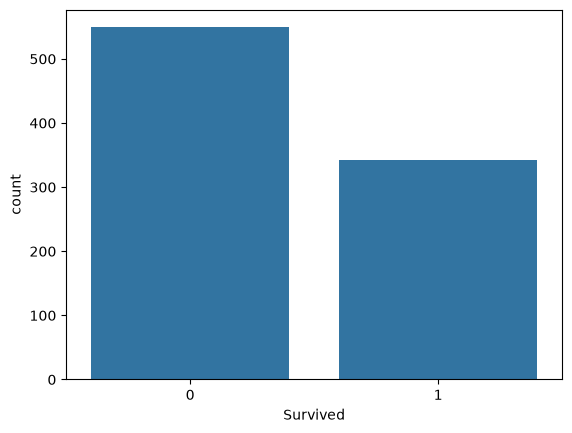

In [7]:
sns.countplot(data=train, x='Survived');

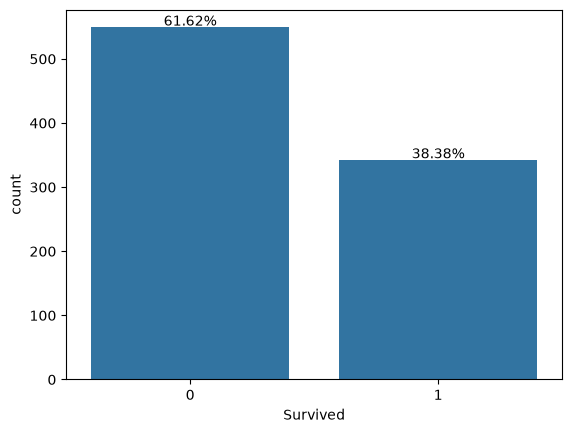

In [8]:
s = sns.countplot(data=train, x='Survived')
size = []
for p in s.patches:
    height = p.get_height()
    size.append(height)
    s.text(p.get_x() + p.get_width() / 2., height + 3, f'{height/len(train)*100:.2f}%', ha='center')


### Deteccion de valores faltantes

deteccion numerica de valores faltantes

In [9]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [12]:
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = df.isnull().sum() / len(train) * 100
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(columns={0:'Missing Values', 1:'% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values('% of Total Values', ascending=False).round(1)

    print(f'El dataframe seleccionado tiene {df.shape[1]} columnas')
    print(f'Hay {mis_val_table_ren_columns.shape[0]} columnas que tienen valores faltantes')

    return mis_val_table_ren_columns

In [13]:
train_missing = missing_values_table(train)
train_missing

El dataframe seleccionado tiene 12 columnas
Hay 3 columnas que tienen valores faltantes


,Missing Values,% of Total Values
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


In [14]:
test_missing = missing_values_table(train)
test_missing

El dataframe seleccionado tiene 12 columnas
Hay 3 columnas que tienen valores faltantes


,Missing Values,% of Total Values
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


### Deteccion visual de datos faltantes con la biblioteca Missingno

<Axes: >

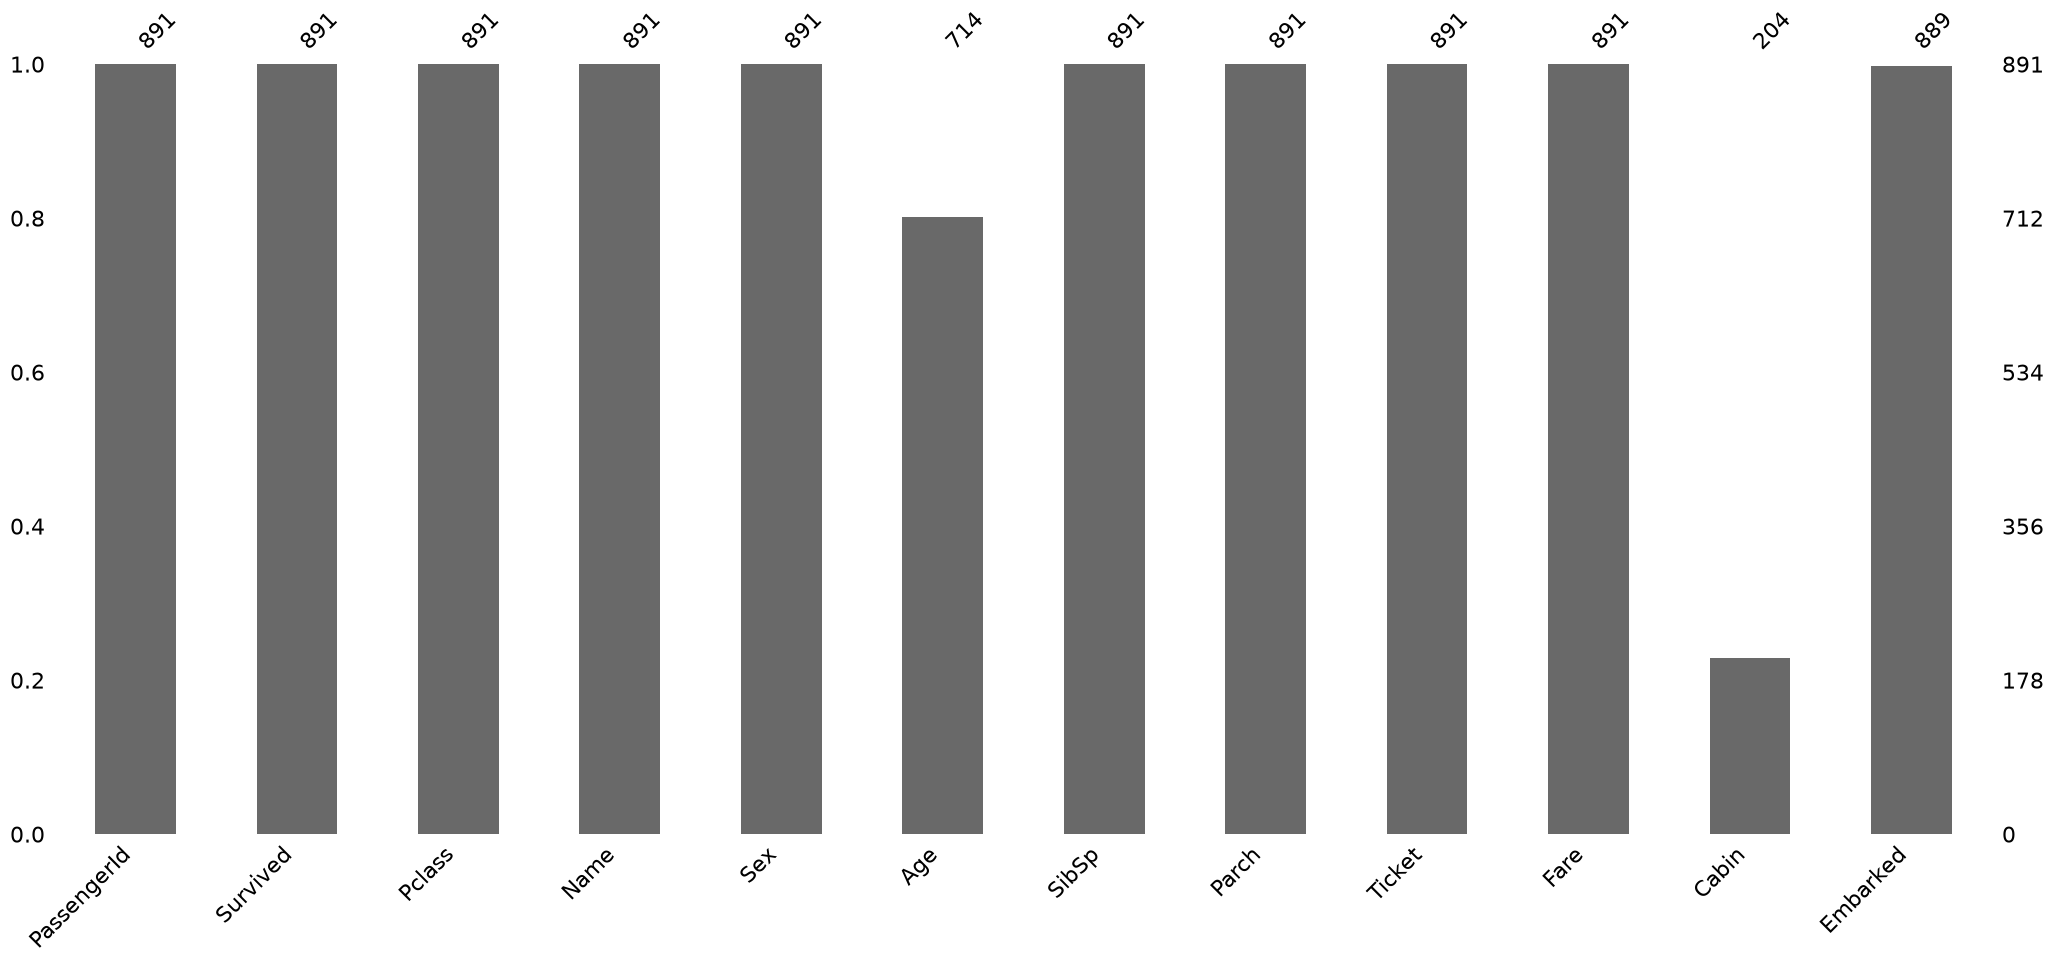

In [15]:
msno.bar(train)

<Axes: >

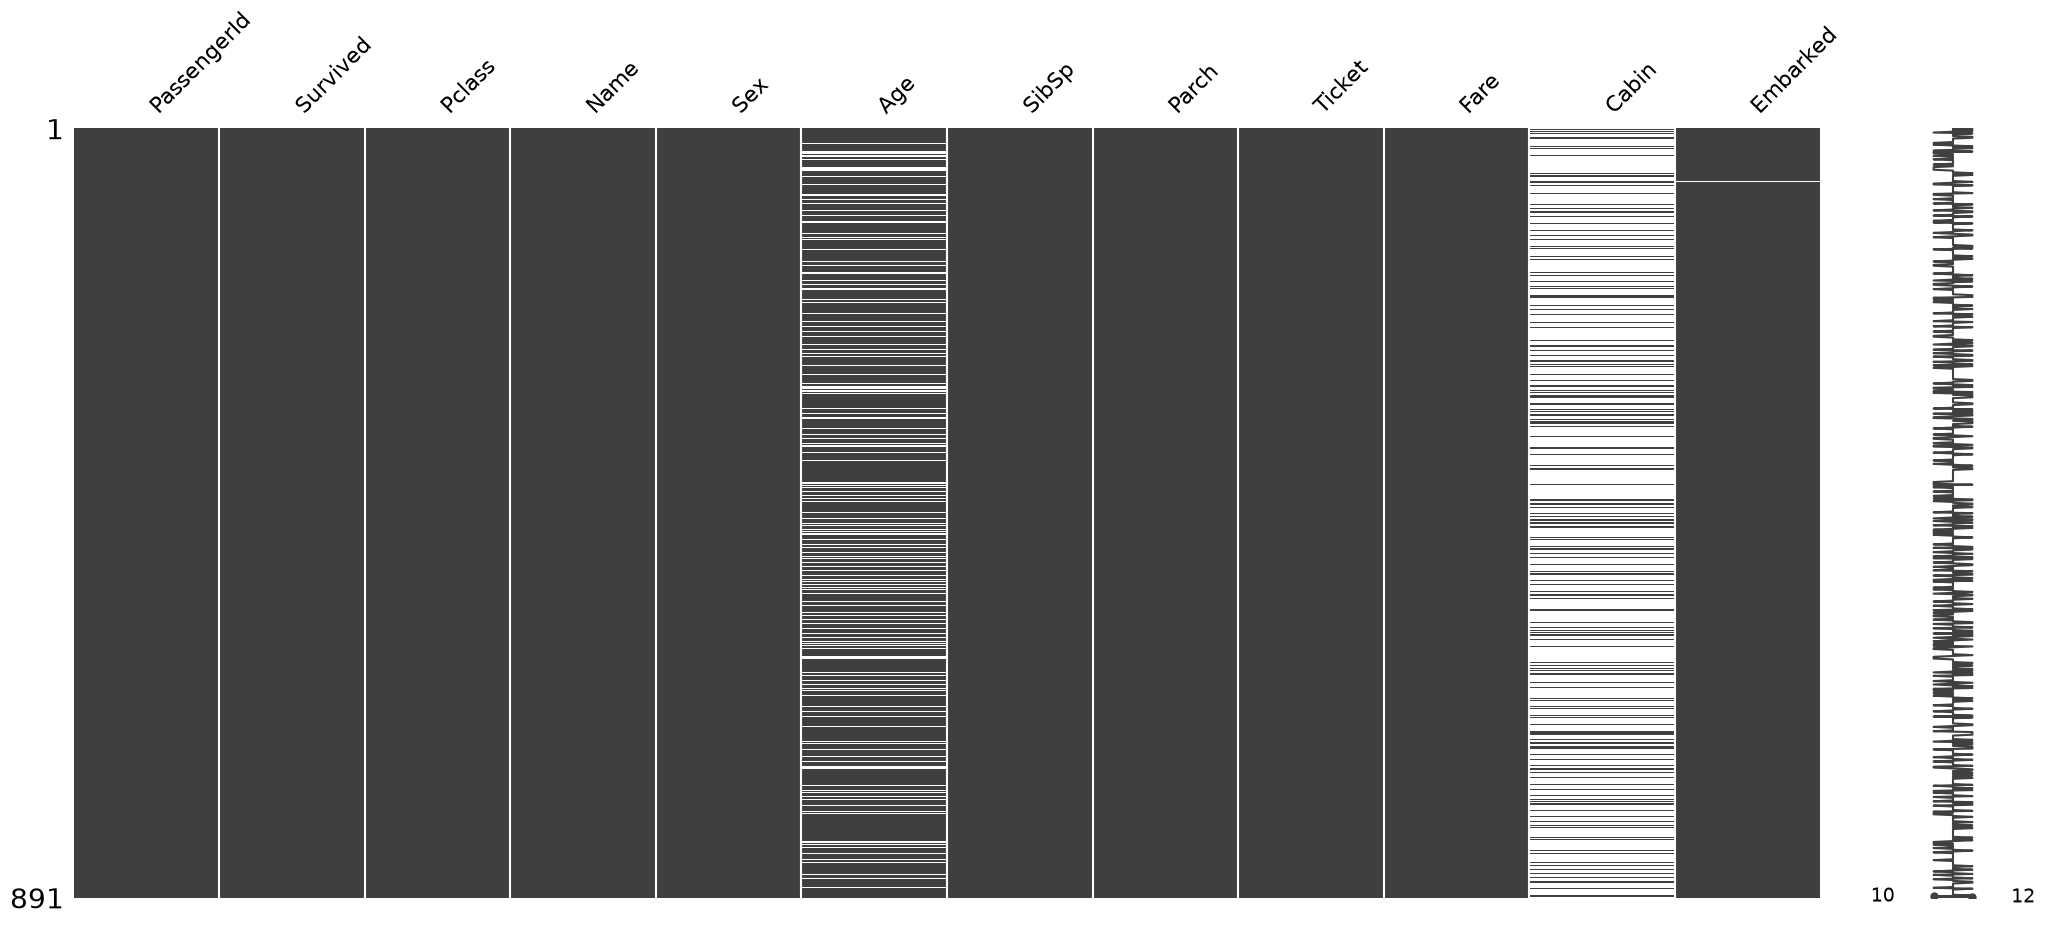

In [16]:
msno.matrix(train)

<Axes: >

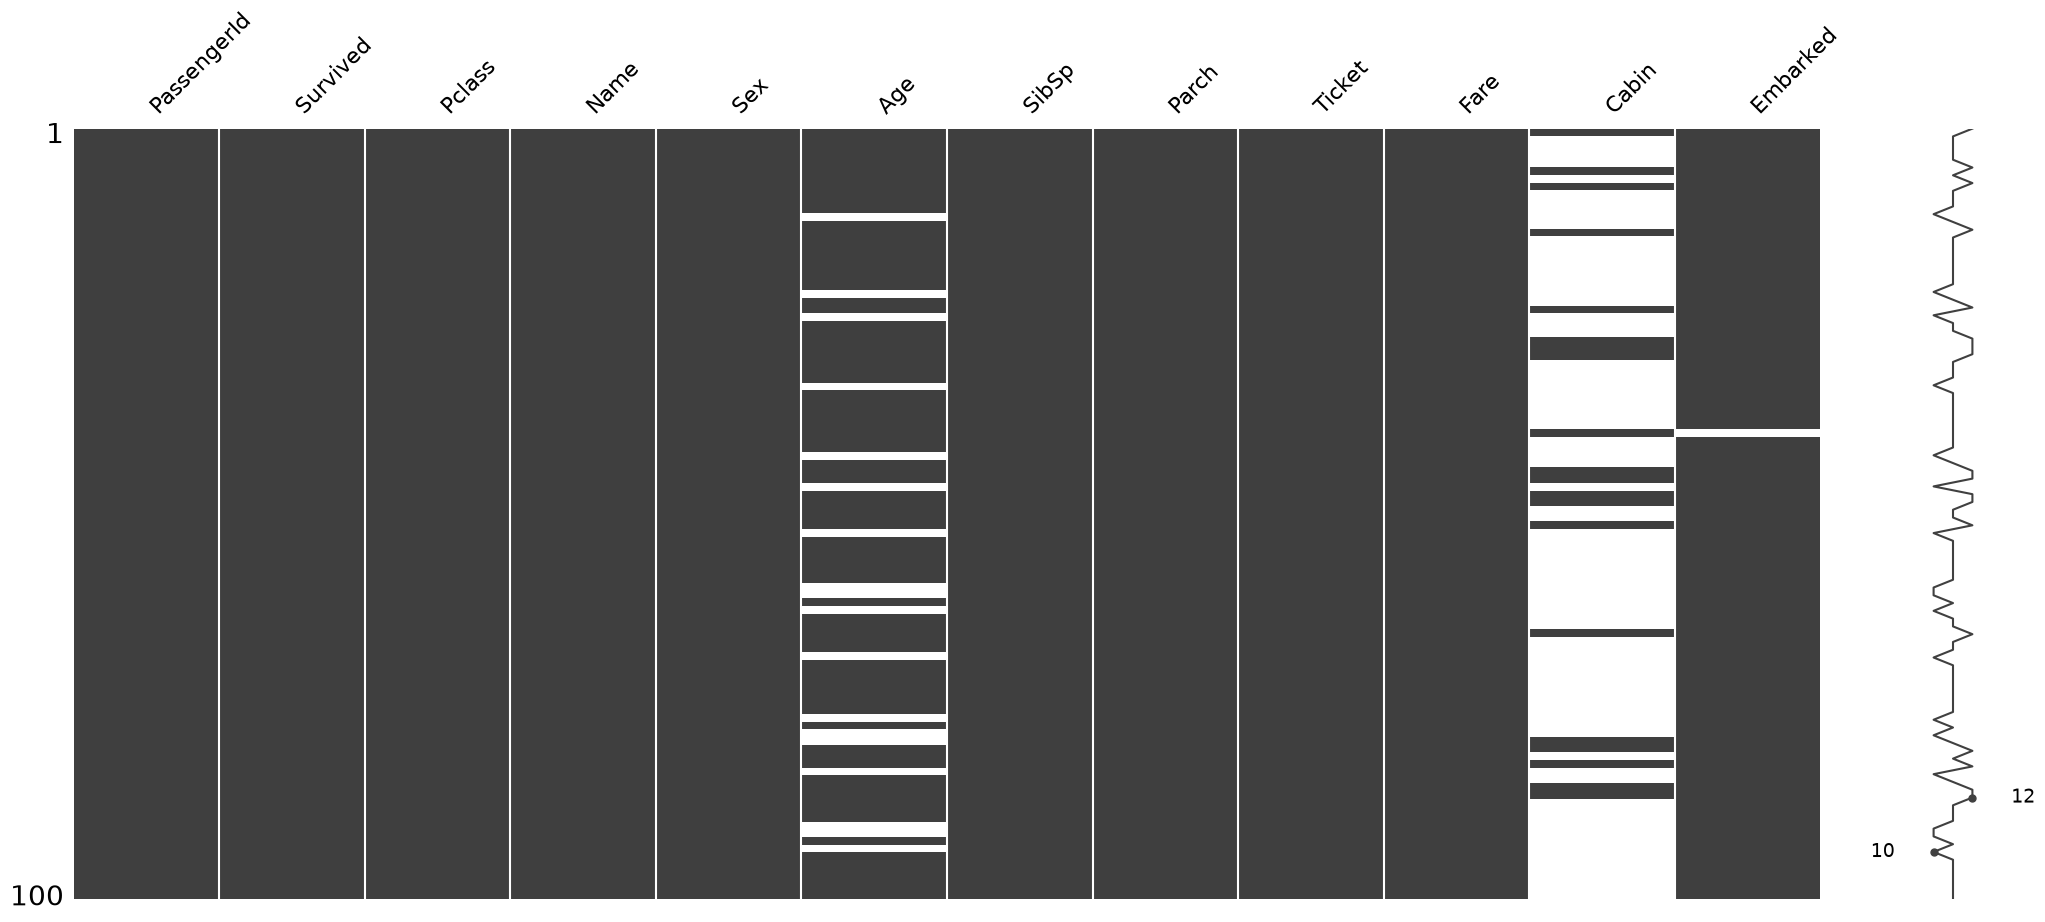

In [18]:
msno.matrix(train.sample(100))

<Axes: >

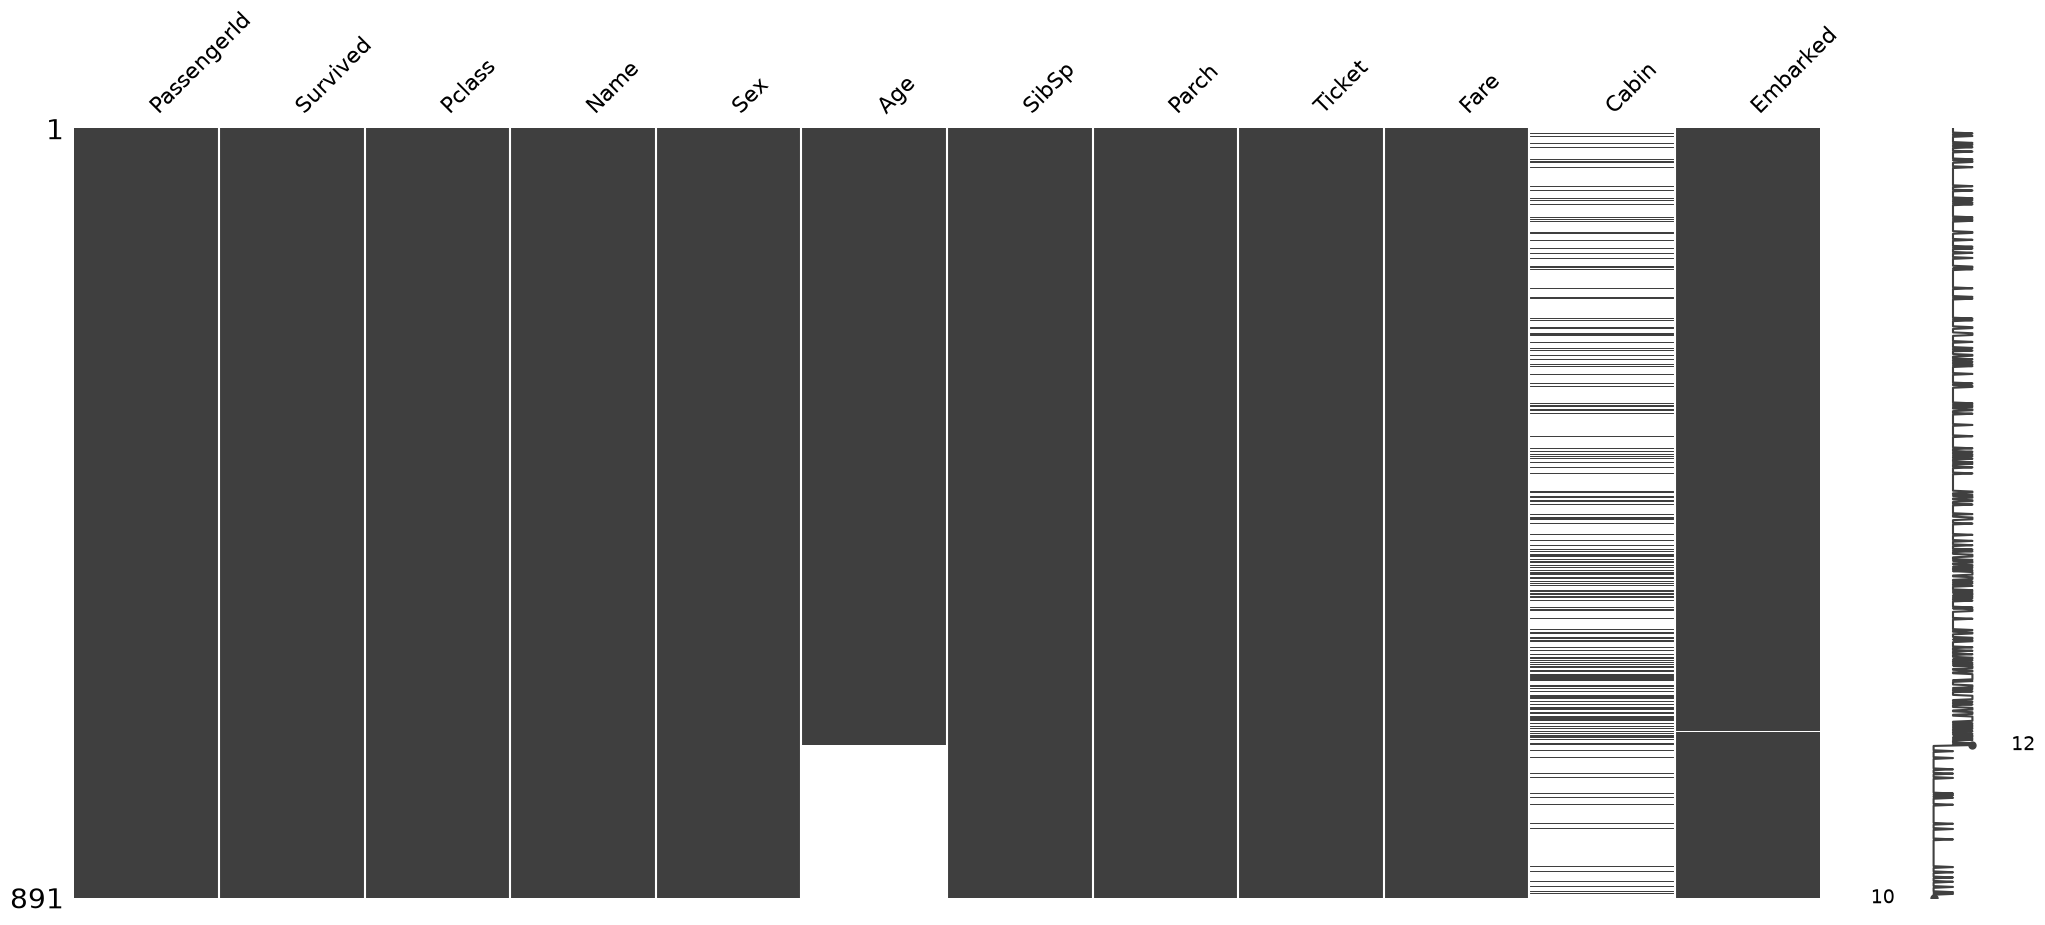

In [19]:
sorted = train.sort_values('Age')
msno.matrix(sorted)

<Axes: >

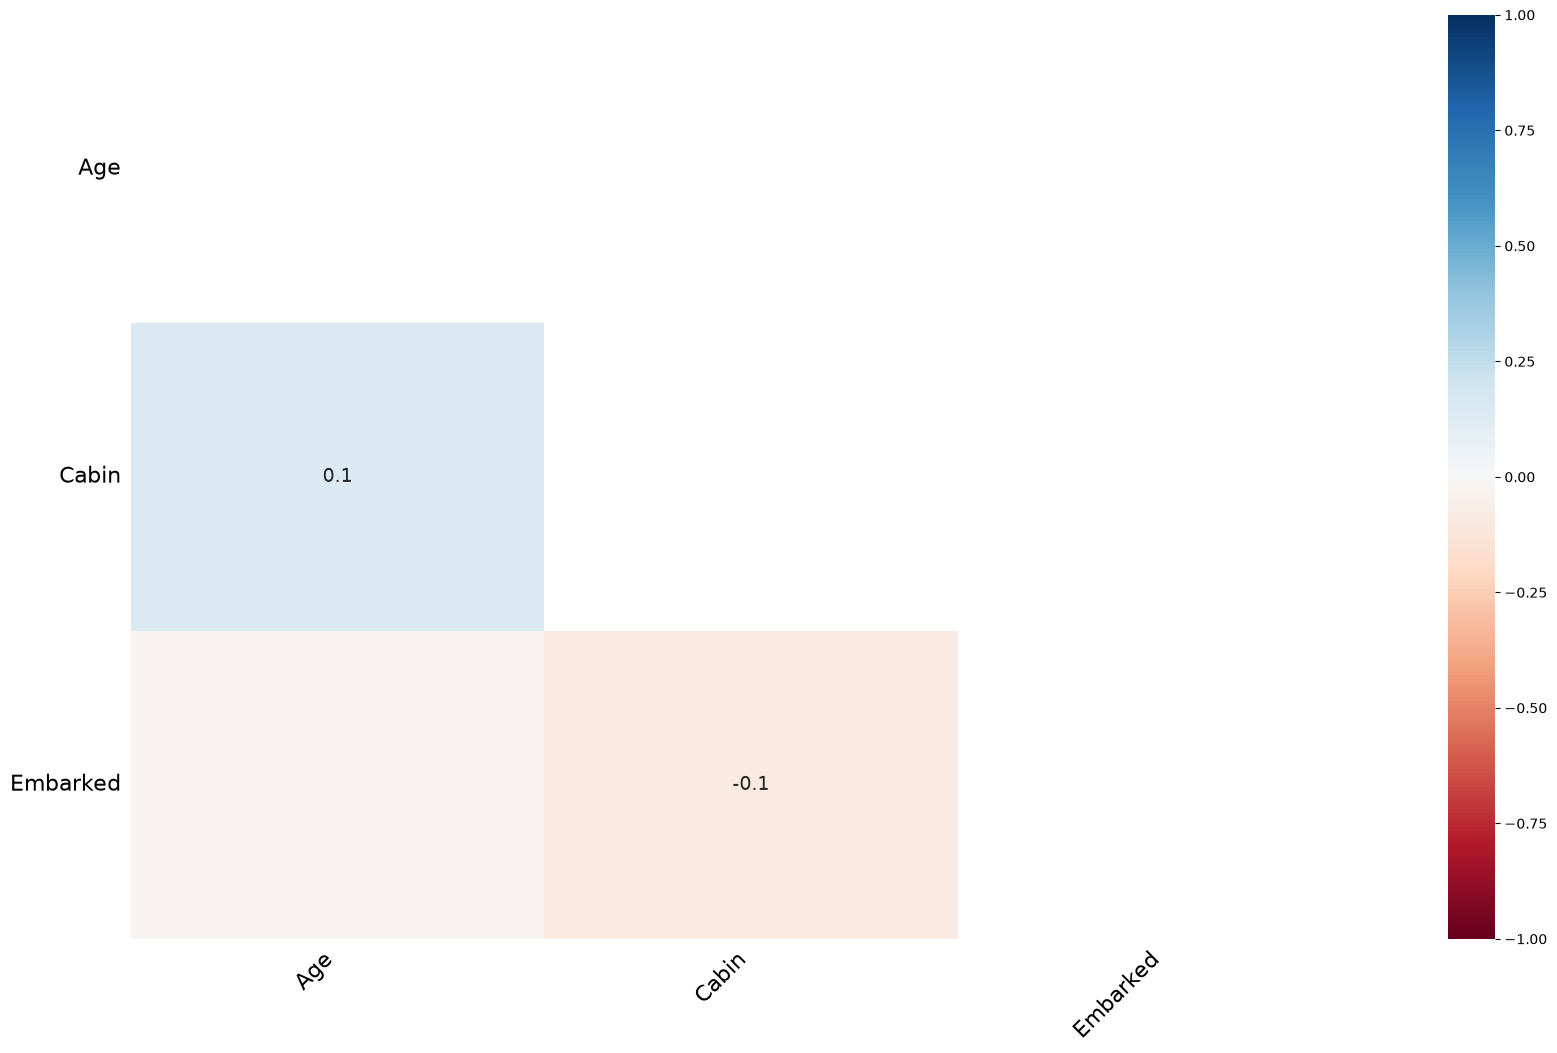

In [20]:
msno.heatmap(train)

<Axes: >

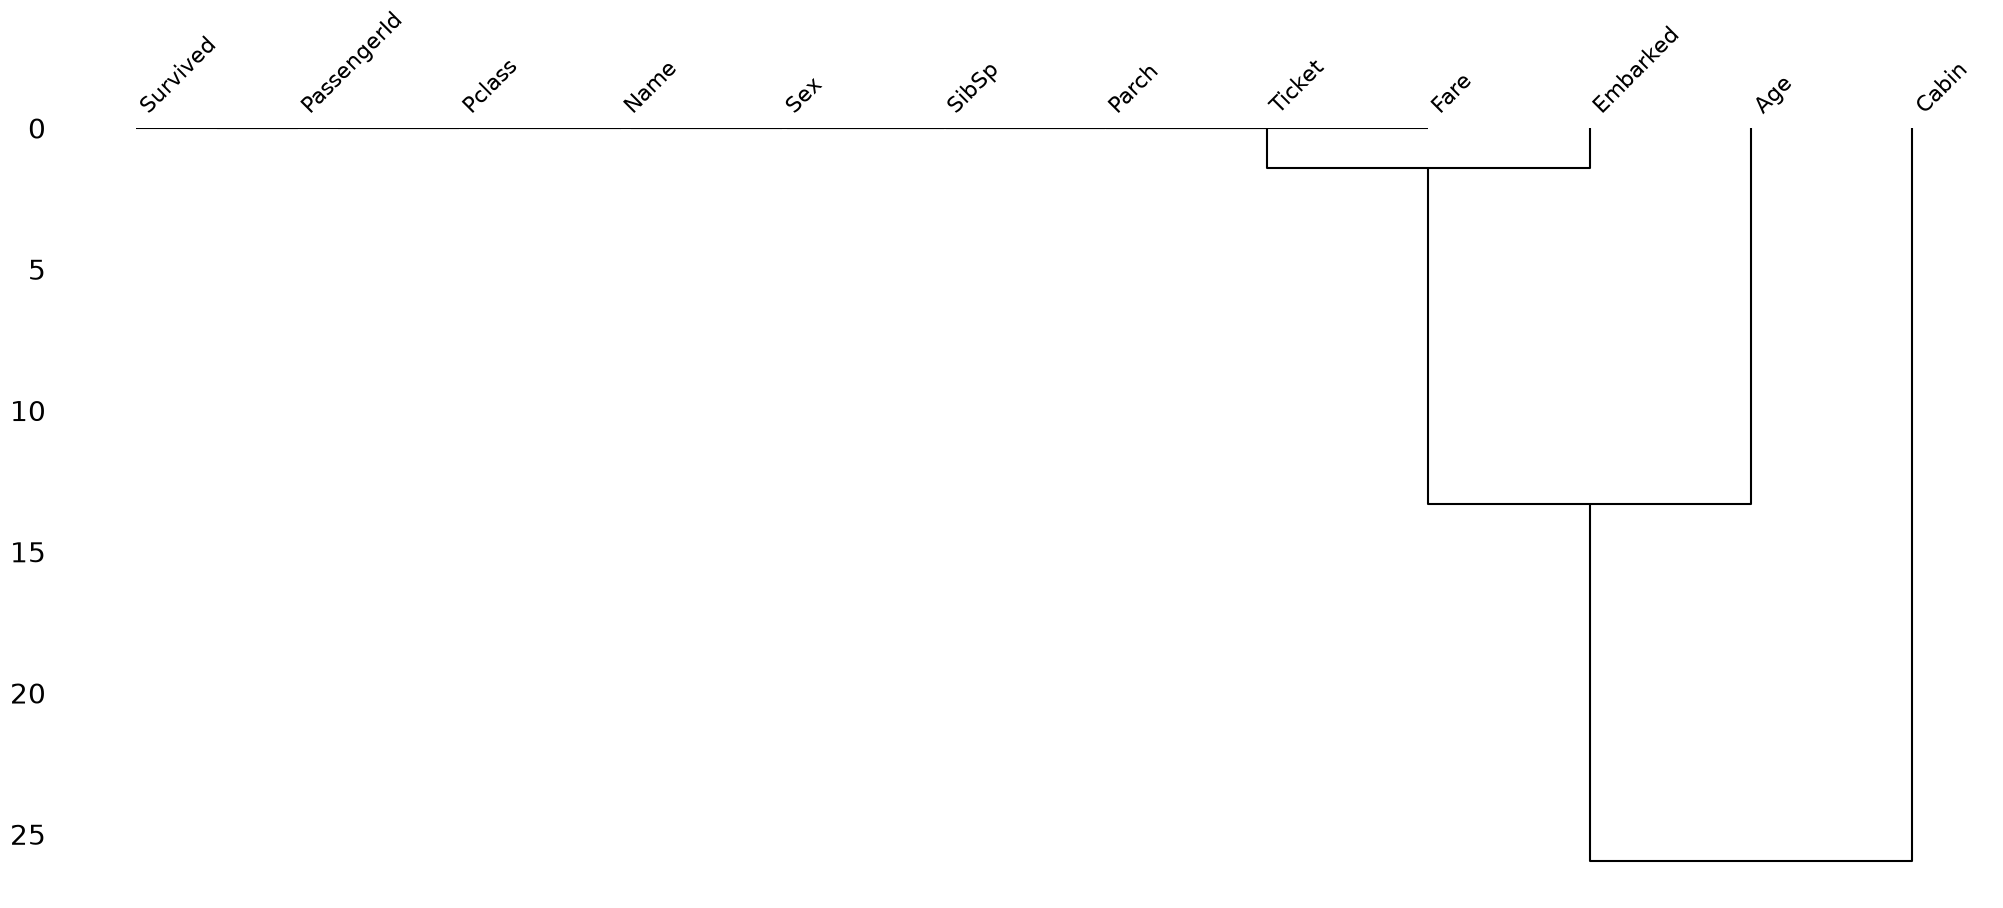

In [21]:
msno.dendrogram(train)

### Tratamiento de valores faltantes

`Eliminacion`

![](https://imgur.com/tBvdfyX.png)

**Eliminacion por pares**

In [22]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [23]:
train_1 = train.copy()
train_1['Age'].mean()

np.float64(29.69911764705882)

In [24]:
train_1 = train_1.fillna(train_1['Age'].mean())
# train_1.fillna(train_1['Age'].mean(), inplace=True)
train_1['Age'].isnull().sum()

np.int64(0)

<Axes: >

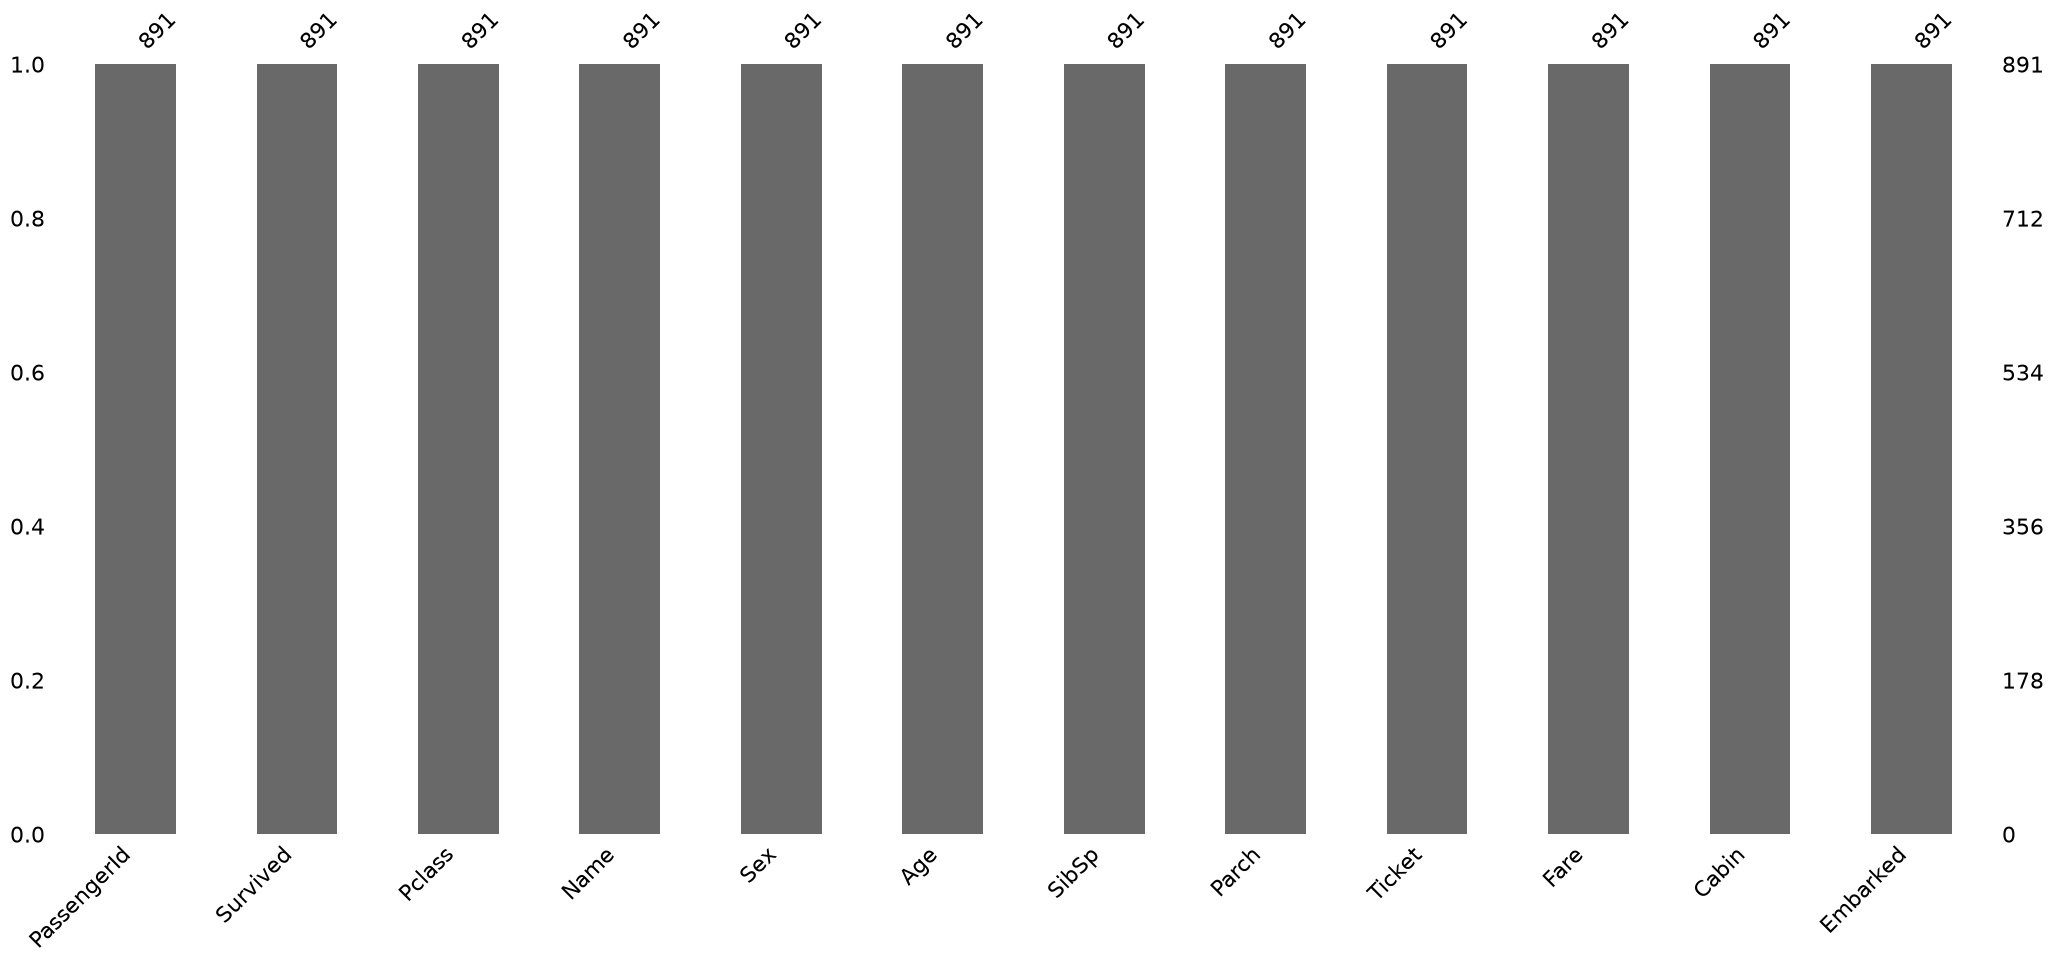

In [25]:
msno.bar(train_1)

**Eliminacion por fila**

In [27]:
train_2 = train.copy()

In [30]:
train_2.dropna(subset=['Age'], how='any', inplace=True)
train_2['Age'].isnull().sum()

np.int64(0)

<Axes: >

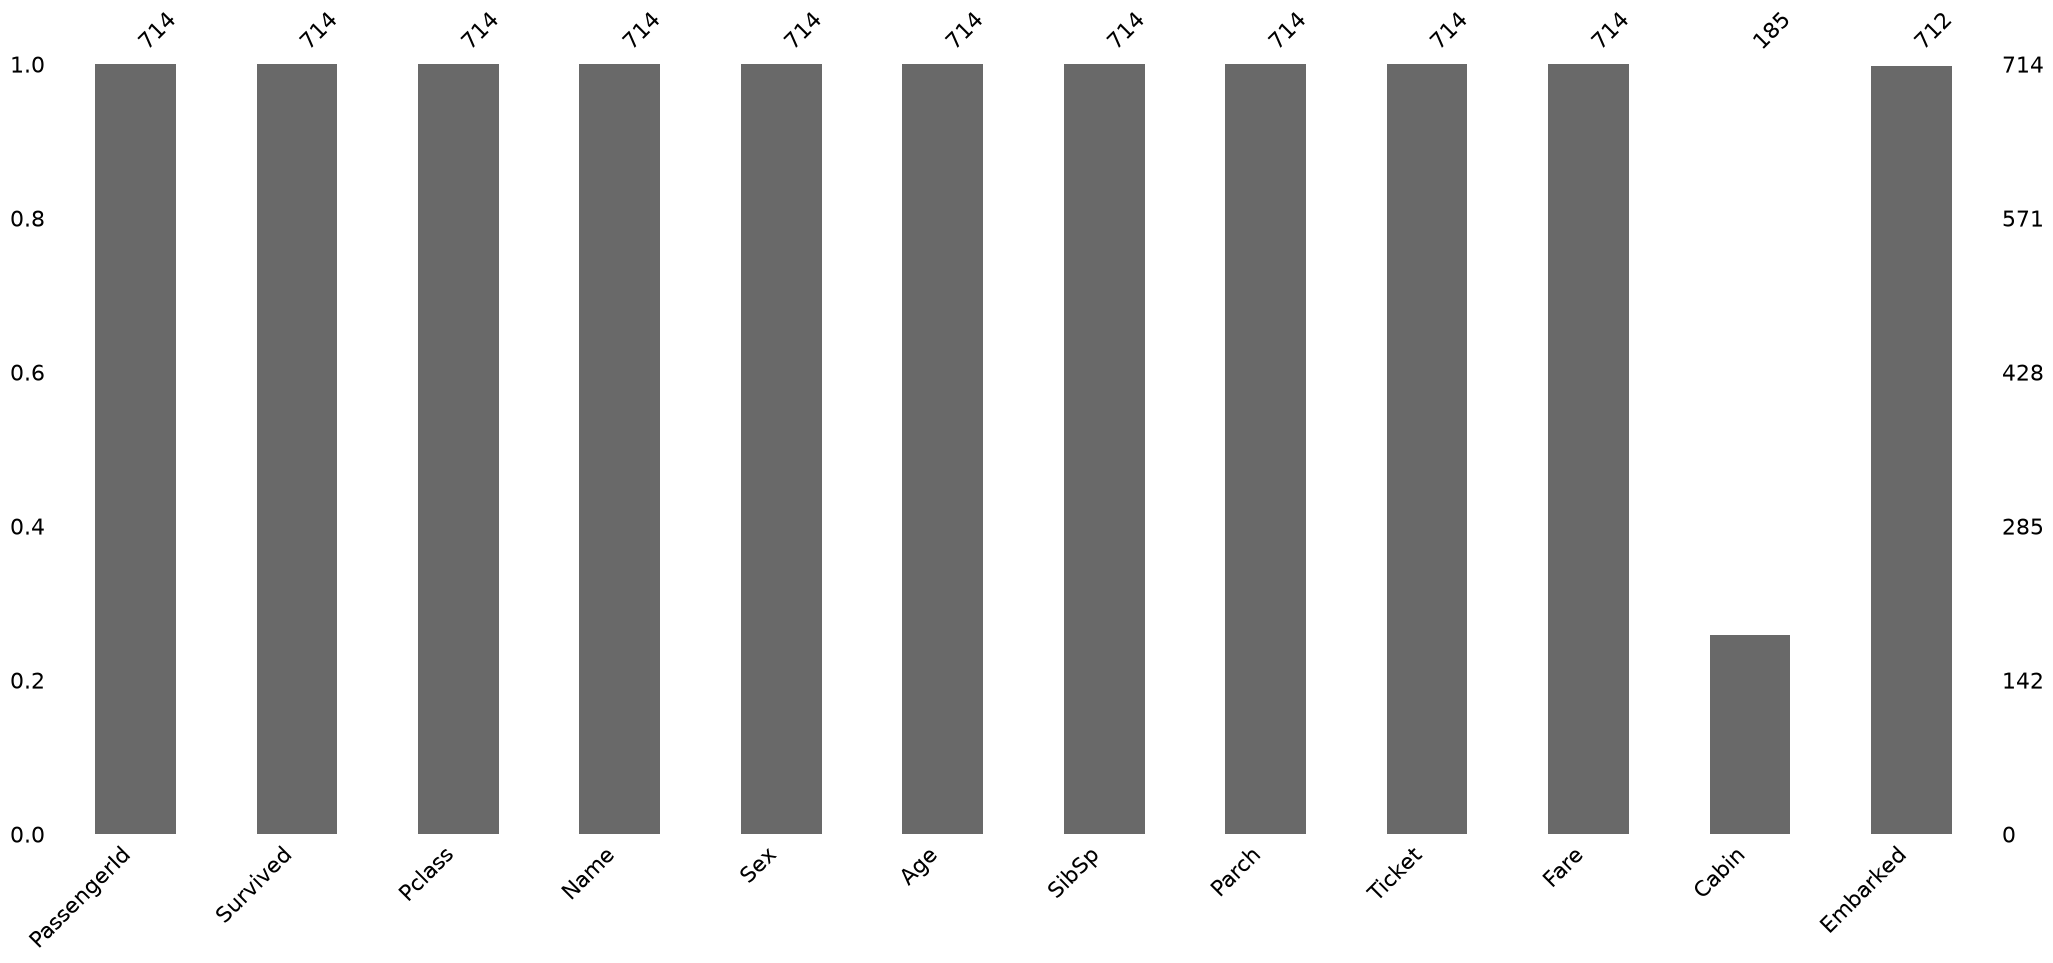

In [31]:
msno.bar(train_2)

**Eliminacion por columna**

<Axes: >

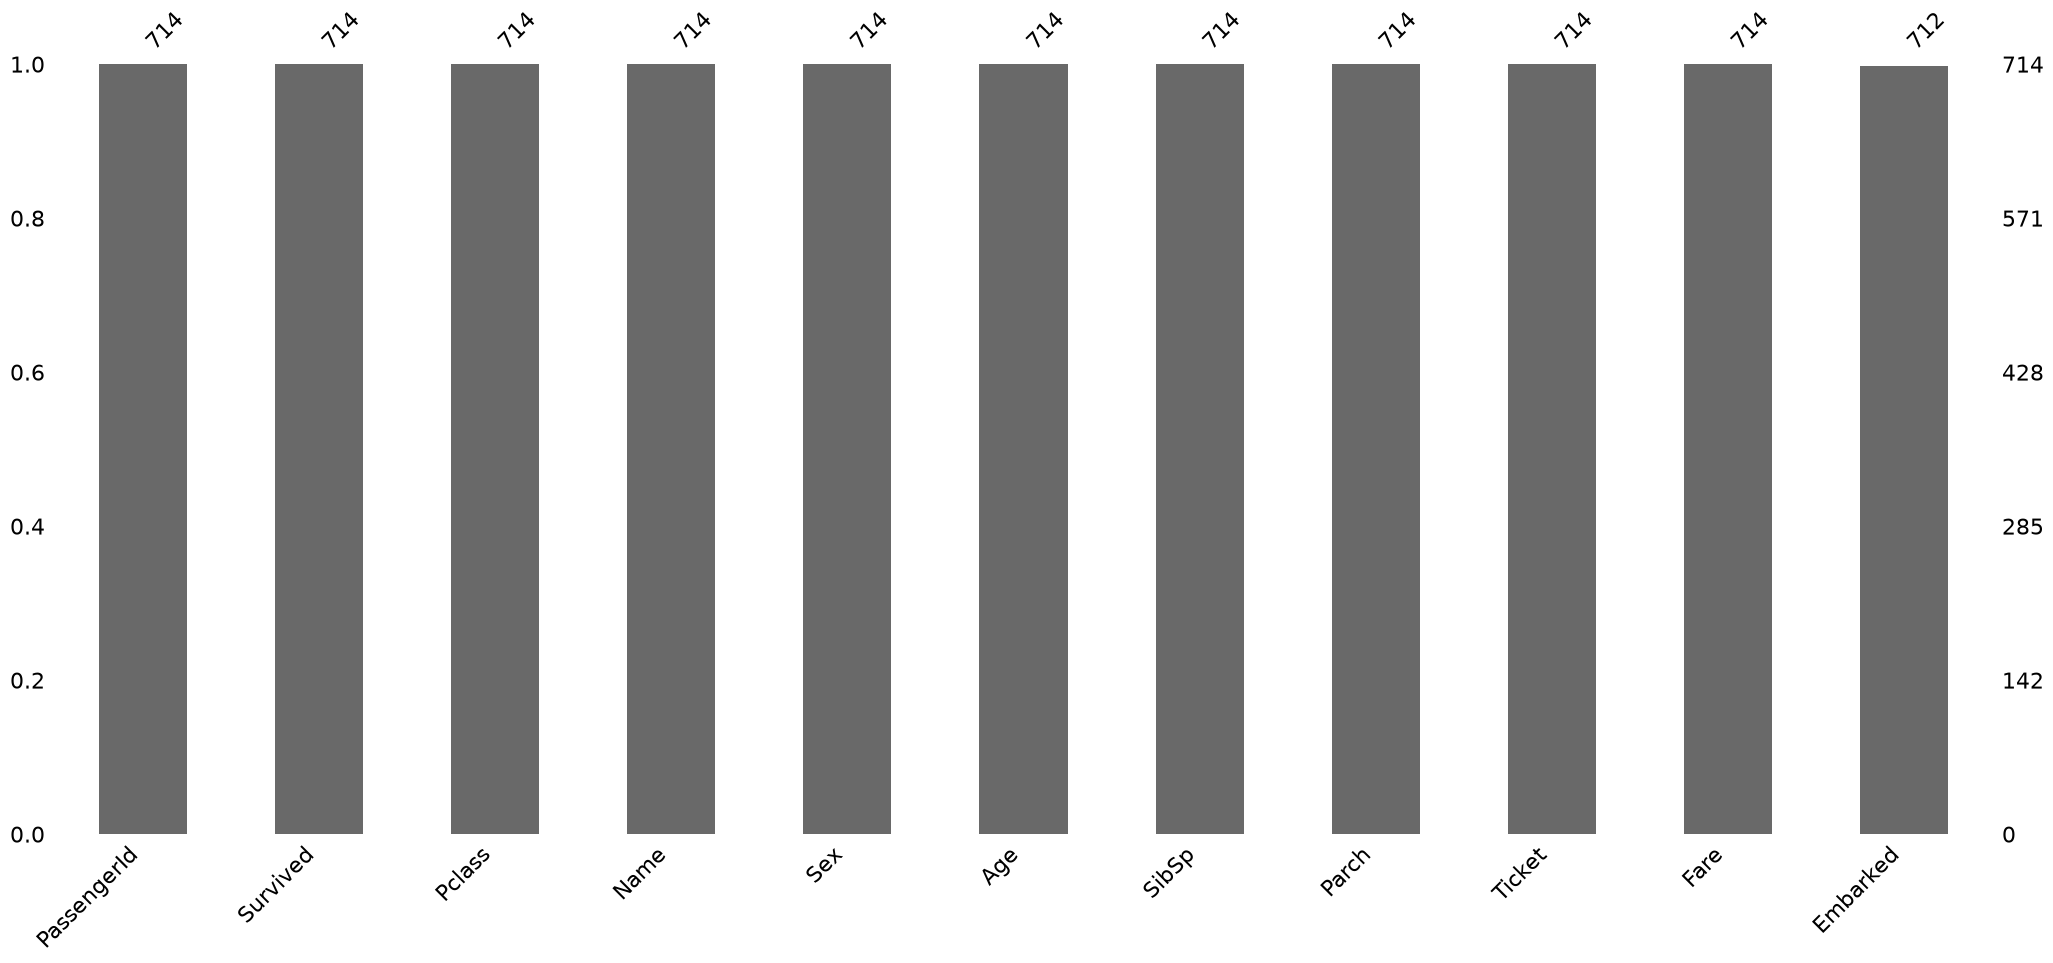

In [32]:
train_2.drop('Cabin', axis=1, inplace=True)
msno.bar(train_2)

### Tratamiento de valores faltantes

`Imputacion`

![](https://imgur.com/bL0iHde.png)

In [33]:
from sklearn.impute import SimpleImputer

In [34]:
help(SimpleImputer)

Help on class SimpleImputer in module sklearn.impute._base:

class SimpleImputer(_BaseImputer)
 |  SimpleImputer(
 |      *,
 |      missing_values=nan,
 |      strategy='mean',
 |      fill_value=None,
 |      copy=True,
 |      add_indicator=False,
 |      keep_empty_features=False
 |  )
 |
 |  Univariate imputer for completing missing values with simple strategies.
 |
 |  Replace missing values using a descriptive statistic (e.g. mean, median, or
 |  most frequent) along each column, or using a constant value.
 |
 |  Read more in the :ref:`User Guide <impute>`.
 |
 |  .. versionadded:: 0.20
 |     `SimpleImputer` replaces the previous `sklearn.preprocessing.Imputer`
 |     estimator which is now removed.
 |
 |  Parameters
 |  ----------
 |  missing_values : int, float, str, np.nan, None or pandas.NA, default=np.nan
 |      The placeholder for the missing values. All occurrences of
 |      `missing_values` will be imputed. For pandas' dataframes with
 |      nullable integer dtypes w